# Step 1: Library Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Load the dataset
print("Loading data...")
df = pd.read_csv("loan_data.csv")

Loading data...


In [3]:
# Display the first few rows and check data types
print(df.head())
print("\nDataset Info:")
print(df.info())

   person_age person_gender person_education  person_income  person_emp_exp  \
0          22        female           Master          71948               0   
1          21        female      High School          12282               0   
2          25        female      High School          12438               3   
3          23        female         Bachelor          79753               0   
4          24          male           Master          66135               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT      35000    PERSONAL          16.02   
1                   OWN       1000   EDUCATION          11.14   
2              MORTGAGE       5500     MEDICAL          12.87   
3                  RENT      35000     MEDICAL          15.23   
4                  RENT      35000     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                           3           561  

# Step 1: Library Imports and Data Loading

In [4]:
# 1. Handle Missing Values dynamically
# Fill missing numerical values (floats/integers) with the median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [5]:
# Fill missing categorical values (objects) with the mode (most frequent)
cat_cols = df.select_dtypes(include=['object', 'category', 'str']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
# 2. Separate features (X) and target (y)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [7]:
# 3. Encode Categorical Variables
# pd.get_dummies converts text categories into binary (1/0) columns
# drop_first=True prevents multicollinearity (the dummy variable trap)
X = pd.get_dummies(X, drop_first=True)

# Step 3: Data Splitting & Feature Scaling

In [8]:
# Split into 80% Training Data and 20% Testing Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Model Building

In [9]:
# We will use the Random Forest Classifier, which handles tabular financial data extremely well and is highly resistant to overfitting.

# Initialize the model with 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the unseen test data
rf_preds = rf_model.predict(X_test_scaled)



# Step 5: Evaluation Metrics and Feature Importance

In [10]:
# Confusion Matrix
print("\nConfusion Matrix:")
# Format: [[True Negatives, False Positives], 
#          [False Negatives, True Positives]]
print(confusion_matrix(y_test, rf_preds))


Confusion Matrix:
[[6817  173]
 [ 457 1553]]


In [11]:
# Classification Report
print("\nClassification Report (Precision, Recall, F1-Score):")
print(classification_report(y_test, rf_preds))


Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      6990
           1       0.90      0.77      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



In [12]:
print("\n--- BUSINESS INSIGHTS ---")
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 5 Drivers for Loan Approval:")
print(feature_importances.head(5).to_string(index=False))


--- BUSINESS INSIGHTS ---
Top 5 Drivers for Loan Approval:
                           Feature  Importance
previous_loan_defaults_on_file_Yes    0.216862
               loan_percent_income    0.167050
                     loan_int_rate    0.156051
                     person_income    0.122969
                         loan_amnt    0.061776


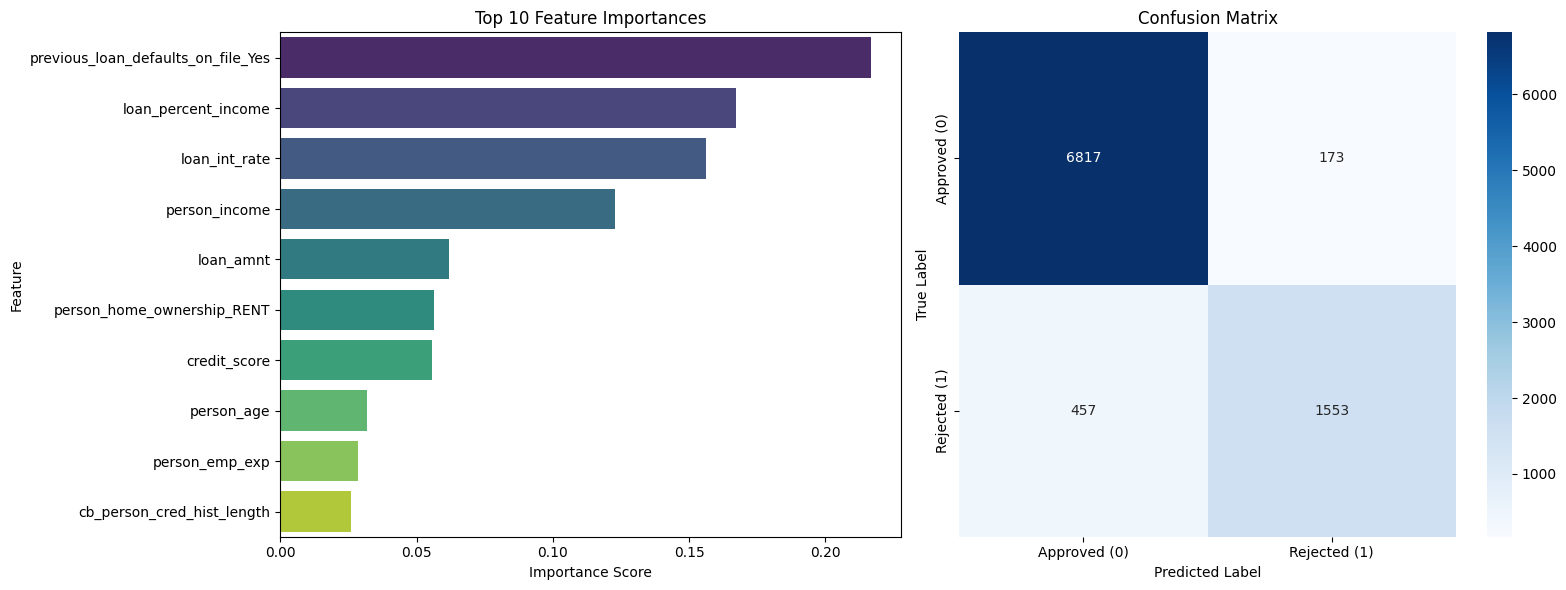

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Feature Importance Plot (updated to fix warning)
sns.barplot(
    data=feature_importances.head(10), 
    x='Importance', 
    y='Feature', 
    hue='Feature',
    legend=False,
    ax=axes[0], 
    palette='viridis'
)
axes[0].set_title('Top 10 Feature Importances')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Feature')

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    ax=axes[1],
    xticklabels=['Approved (0)', 'Rejected (1)'],
    yticklabels=['Approved (0)', 'Rejected (1)']
)
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# new loan


In [14]:
# 1. Create a dictionary with the new applicant's data
new_applicant = pd.DataFrame([{
    'person_age': 28,
    'person_income': 75000,
    'person_emp_exp': 5,
    'loan_amnt': 15000,
    'loan_int_rate': 10.5,
    'loan_percent_income': 0.20,
    'cb_person_cred_hist_length': 4,
    'credit_score': 720,
    'person_gender_male': 1,
    'person_education_Bachelor': 1,
    'person_education_Doctorate': 0,
    'person_education_High School': 0,
    'person_education_Master': 0,
    'person_home_ownership_OTHER': 0,
    'person_home_ownership_OWN': 0,
    'person_home_ownership_RENT': 1,
    'loan_intent_EDUCATION': 0,
    'loan_intent_HOMEIMPROVEMENT': 0,
    'loan_intent_MEDICAL': 0,
    'loan_intent_PERSONAL': 1,
    'loan_intent_VENTURE': 0,
    'previous_loan_defaults_on_file_Yes': 0
}])

# 2. Scale the new data using the ALREADY TRAINED scaler
new_applicant_scaled = scaler.transform(new_applicant)

# 3. Make the prediction
prediction = rf_model.predict(new_applicant_scaled)

if prediction[0] == 1:
    print("Result: Loan APPROVED")
else:
    print("Result: Loan REJECTED")

Result: Loan REJECTED
